## Detrending the seasonality from the data

Detrend the data, then normalise the residual for GP.

Geopotential units: [m^2 s^-2] \
2m temp units: [K]

In [1]:
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
from pandas.plotting import register_matplotlib_converters

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import seasonal_decompose

register_matplotlib_converters()
sns.set_style("darkgrid")

In [2]:
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=7)

In [3]:
# Data
z500 = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/geopotential_500/*.nc', combine='by_coords')
data = z500.sel(time=slice('2015', '2017'))
point_worst = data['z'].sel(lat=50, lon=225, method='nearest')
point_best = data['z'].sel(lat=19.6875, lon=270, method='nearest')

We can use periodogram to extract possible periodicity

Peak at frequency = 0.00011 cycles/hour (corresponding period = 8768.00 hrs = 365.33 days = 12.18 months), power = 250577696.00000
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs = 0.50 days = 0.02 months), power = 110525048.00000
Peak at frequency = 0.00080 cycles/hour (corresponding period = 1252.57 hrs = 52.19 days = 1.74 months), power = 43741800.00000
Peak at frequency = 0.00019 cycles/hour (corresponding period = 5260.80 hrs = 219.20 days = 7.31 months), power = 31677228.00000
Peak at frequency = 0.00034 cycles/hour (corresponding period = 2922.67 hrs = 121.78 days = 4.06 months), power = 24100296.00000
Peak at frequency = 0.00004 cycles/hour (corresponding period = 26304.00 hrs = 1096.00 days = 36.53 months), power = 20946390.00000


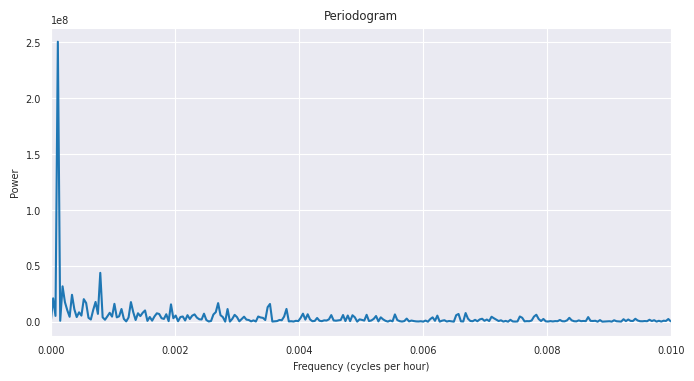

In [35]:
from scipy.signal import periodogram, find_peaks
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_best.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:6]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.01)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

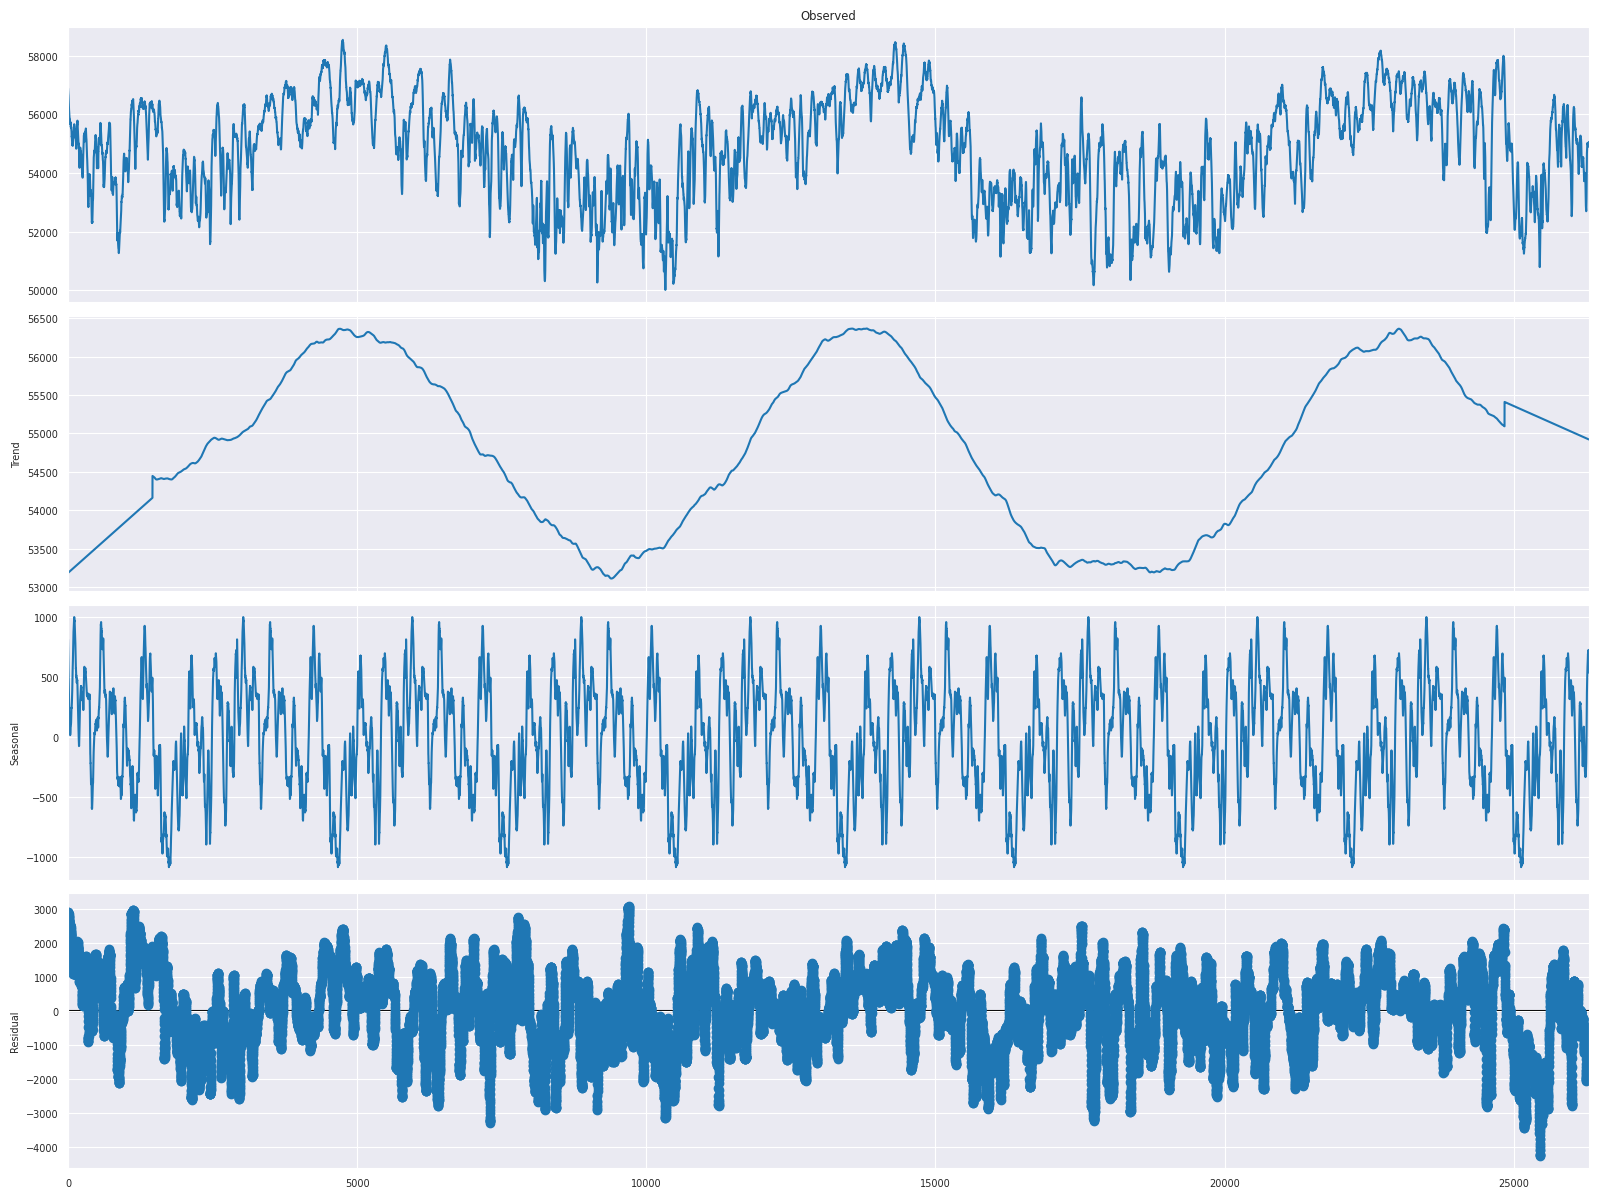

In [85]:
detrend_point_worst = seasonal_decompose(point_worst.values, period=2923, extrapolate_trend='freq')
detrend_point_worst.plot()
plt.show()

[]

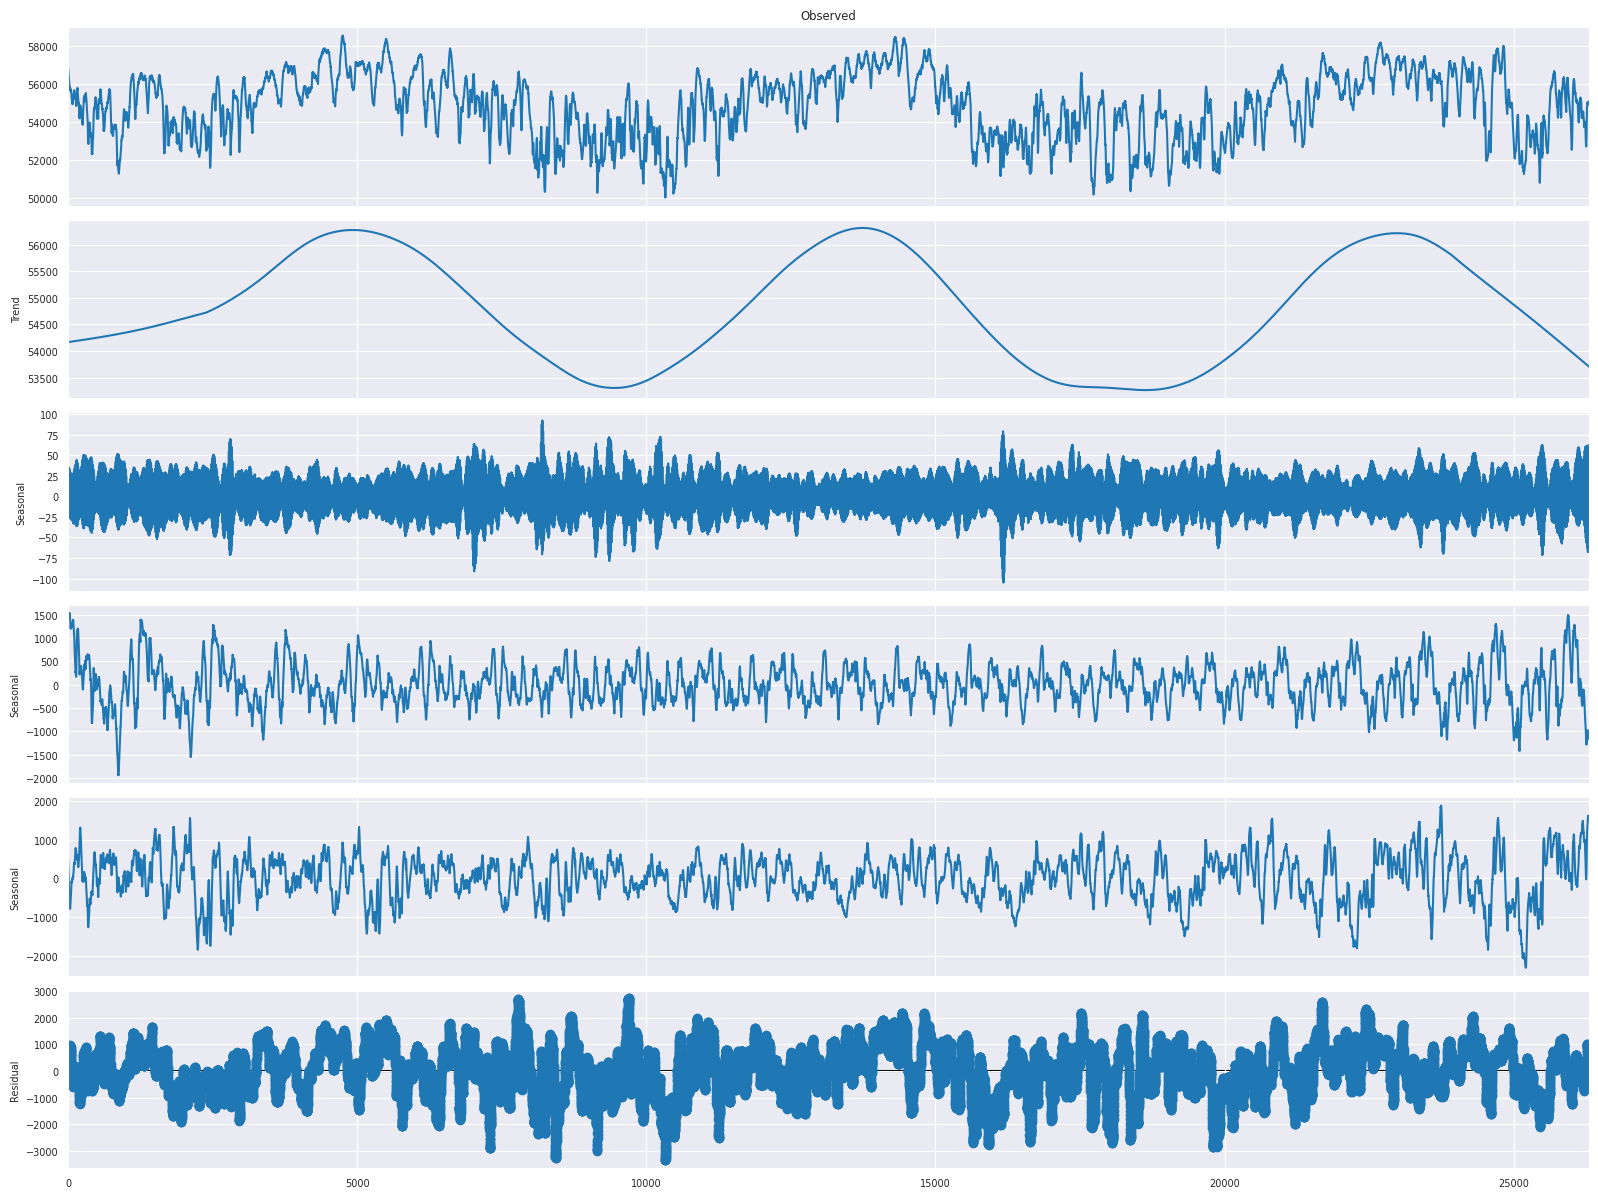

In [66]:
detrend_point_worst = MSTL(point_worst, periods=[12, 1253, 2923])
residual_point_worst = detrend_point_worst.fit()
residual_point_worst.plot()
plt.plot()

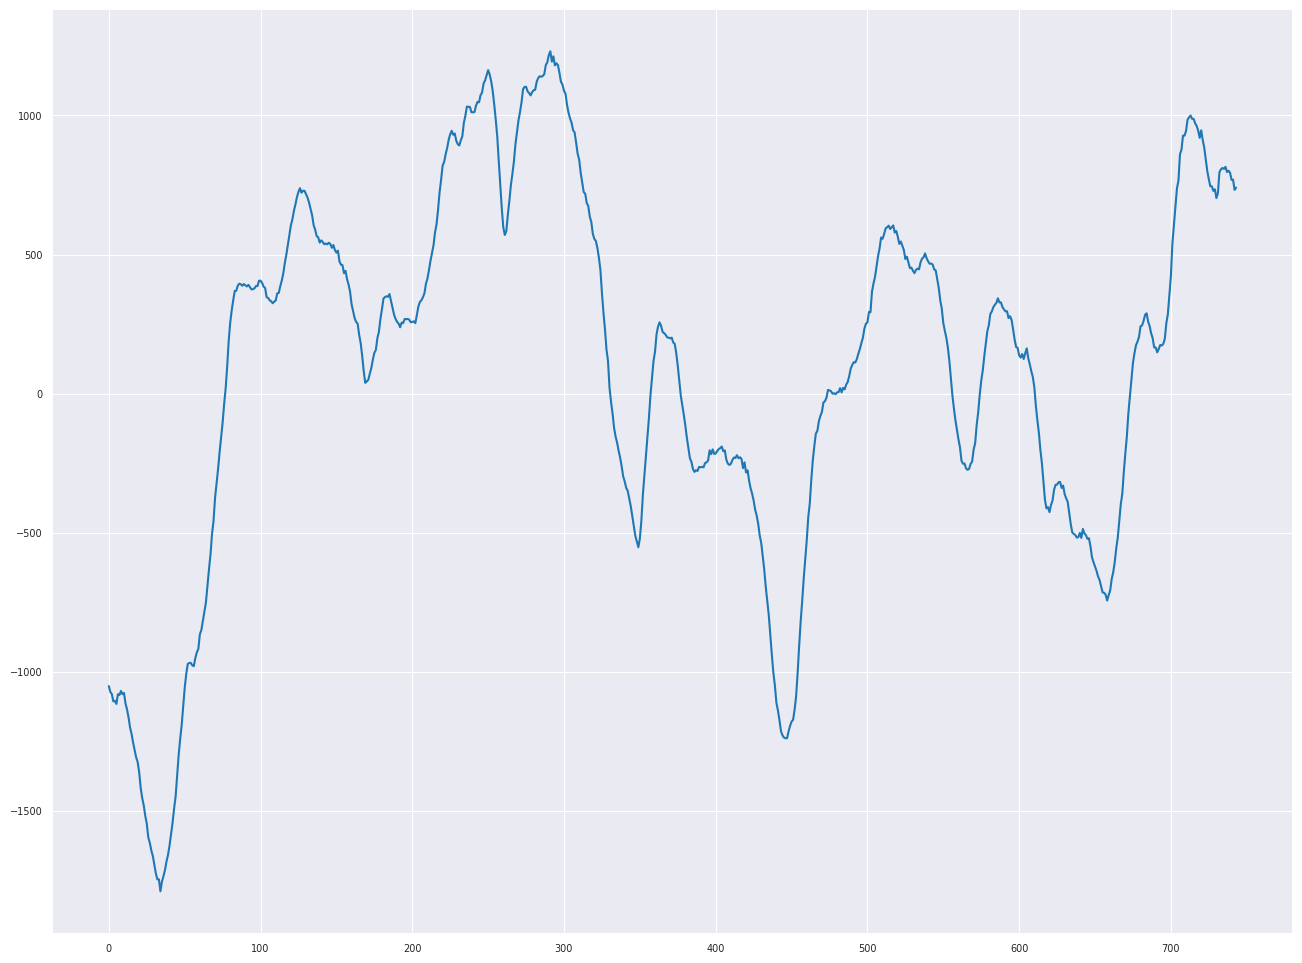

In [68]:
# Residuals during 2017/12
plt.plot(residual_point_worst.resid[25560:])
plt.show()

Peak at frequency = 0.00011 cycles/hour (corresponding period = 8768.00 hrs = 365.33 days = 12.18 months), power = 33358352384.00000
Peak at frequency = 0.00023 cycles/hour (corresponding period = 4384.00 hrs = 182.67 days = 6.09 months), power = 2177601792.00000
Peak at frequency = 0.00004 cycles/hour (corresponding period = 26304.00 hrs = 1096.00 days = 36.53 months), power = 2092346112.00000
Peak at frequency = 0.00030 cycles/hour (corresponding period = 3288.00 hrs = 137.00 days = 4.57 months), power = 1639805056.00000
Peak at frequency = 0.00095 cycles/hour (corresponding period = 1052.16 hrs = 43.84 days = 1.46 months), power = 1101424384.00000
Peak at frequency = 0.00137 cycles/hour (corresponding period = 730.67 hrs = 30.44 days = 1.01 months), power = 826652736.00000


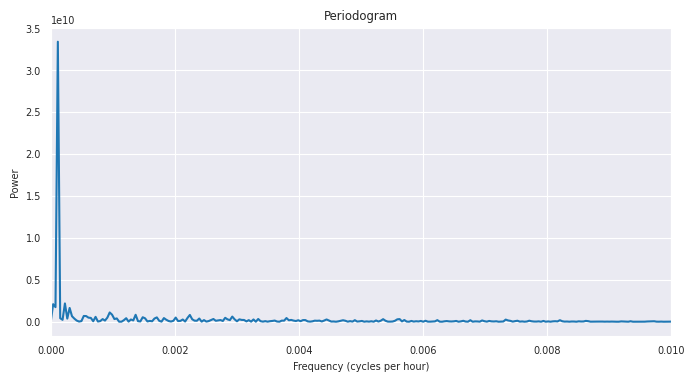

In [76]:
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_worst.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:6]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.01)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

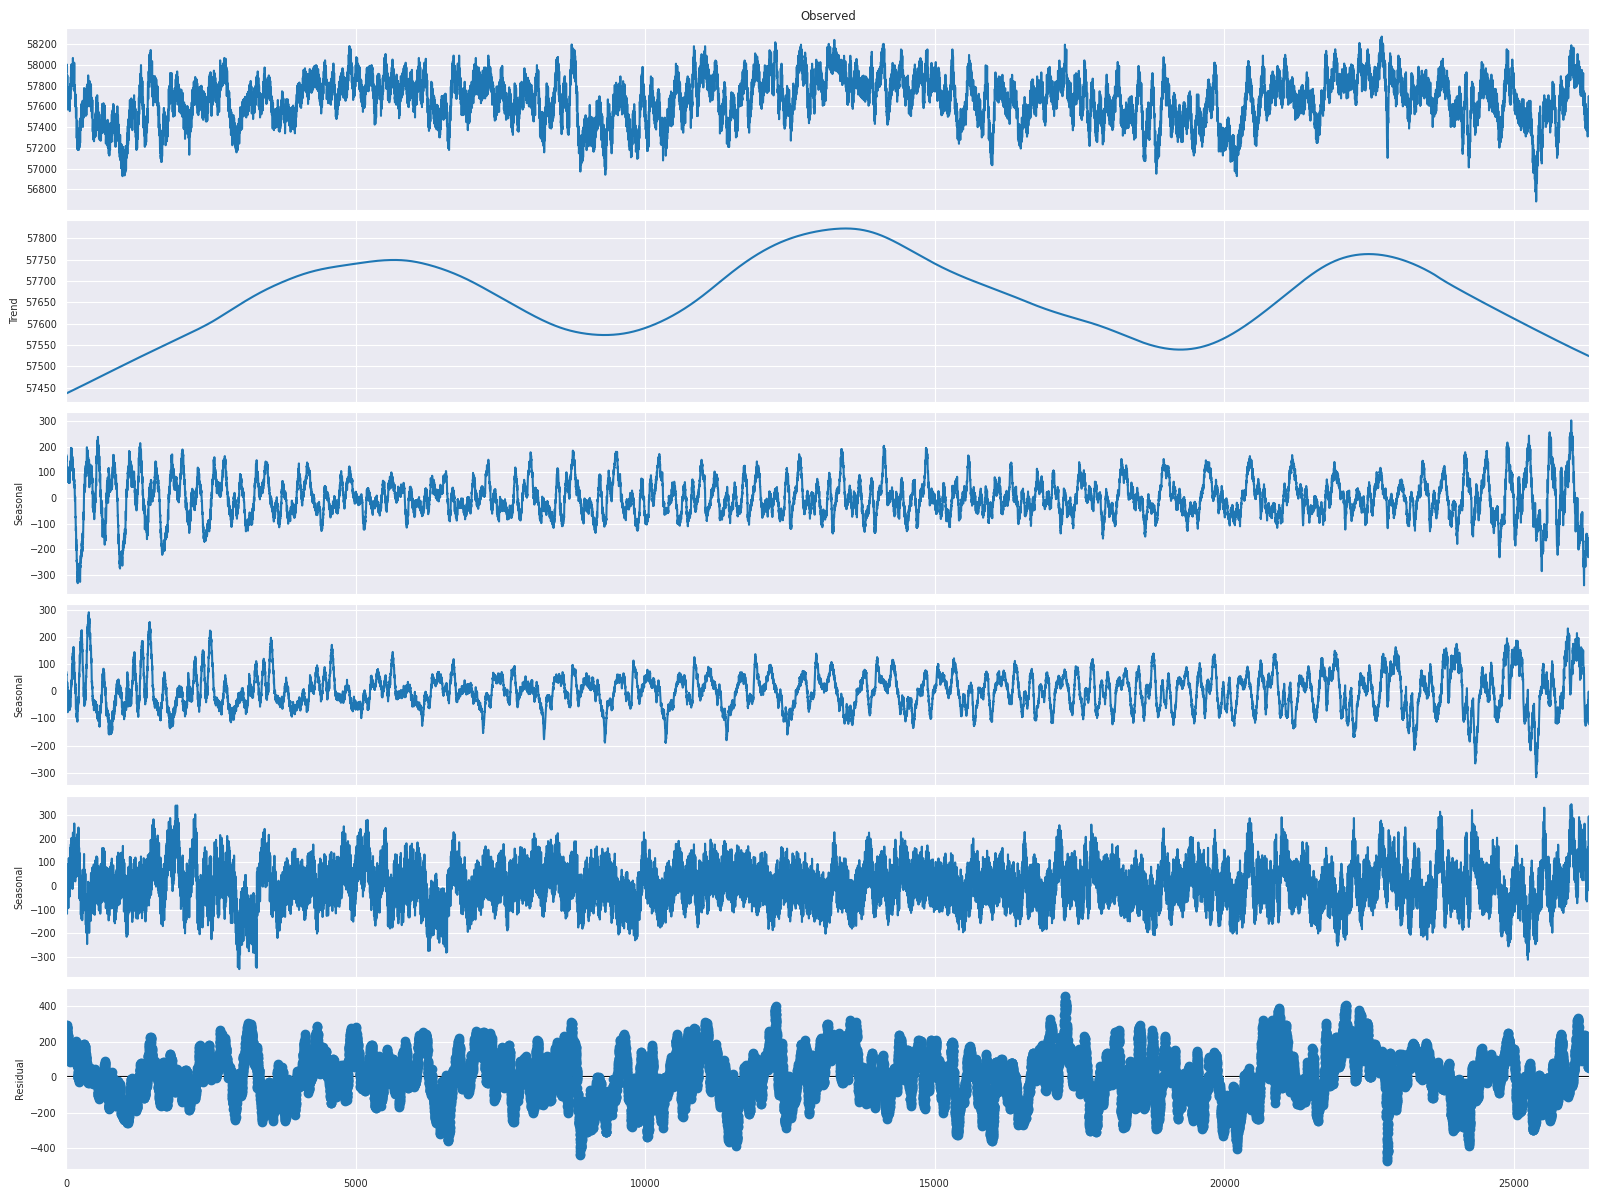

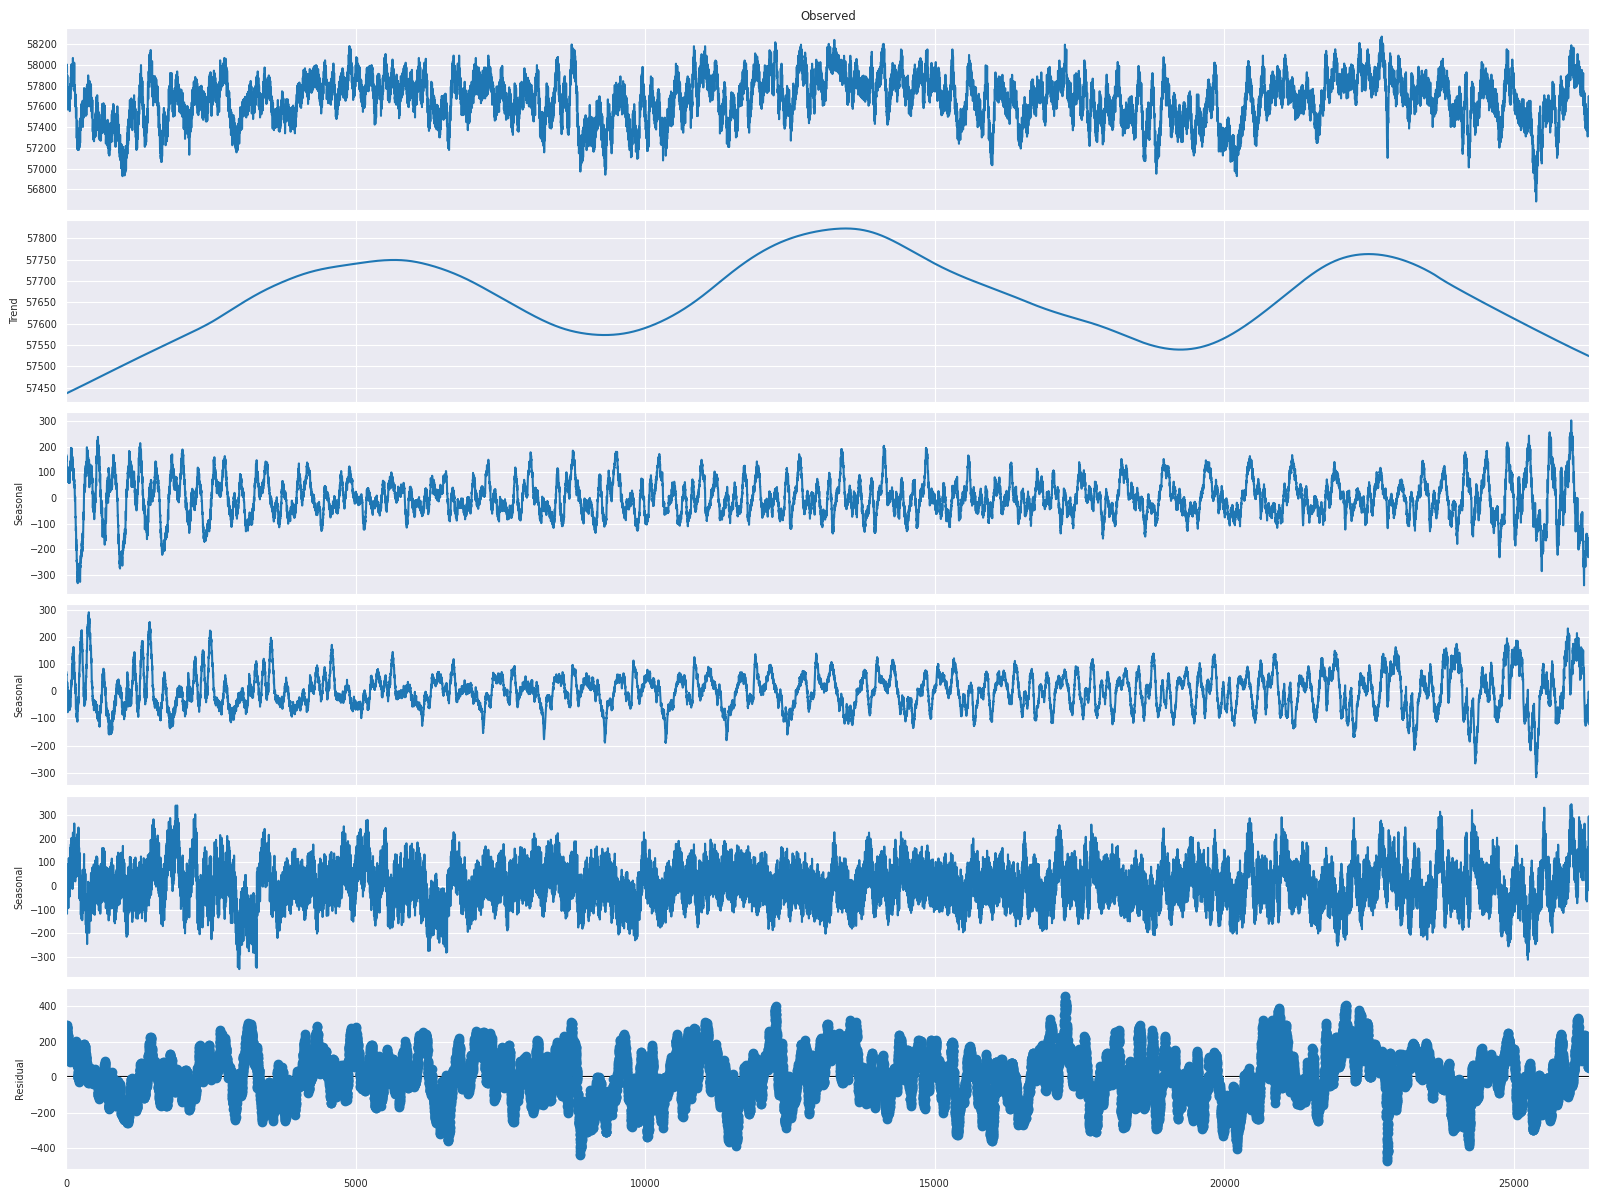

In [ ]:
detrend_point_best = MSTL(point_best, periods=[730, 1052, 3288])
residual_point_best = detrend_point_best.fit()
residual_point_best.plot()
plt.show()

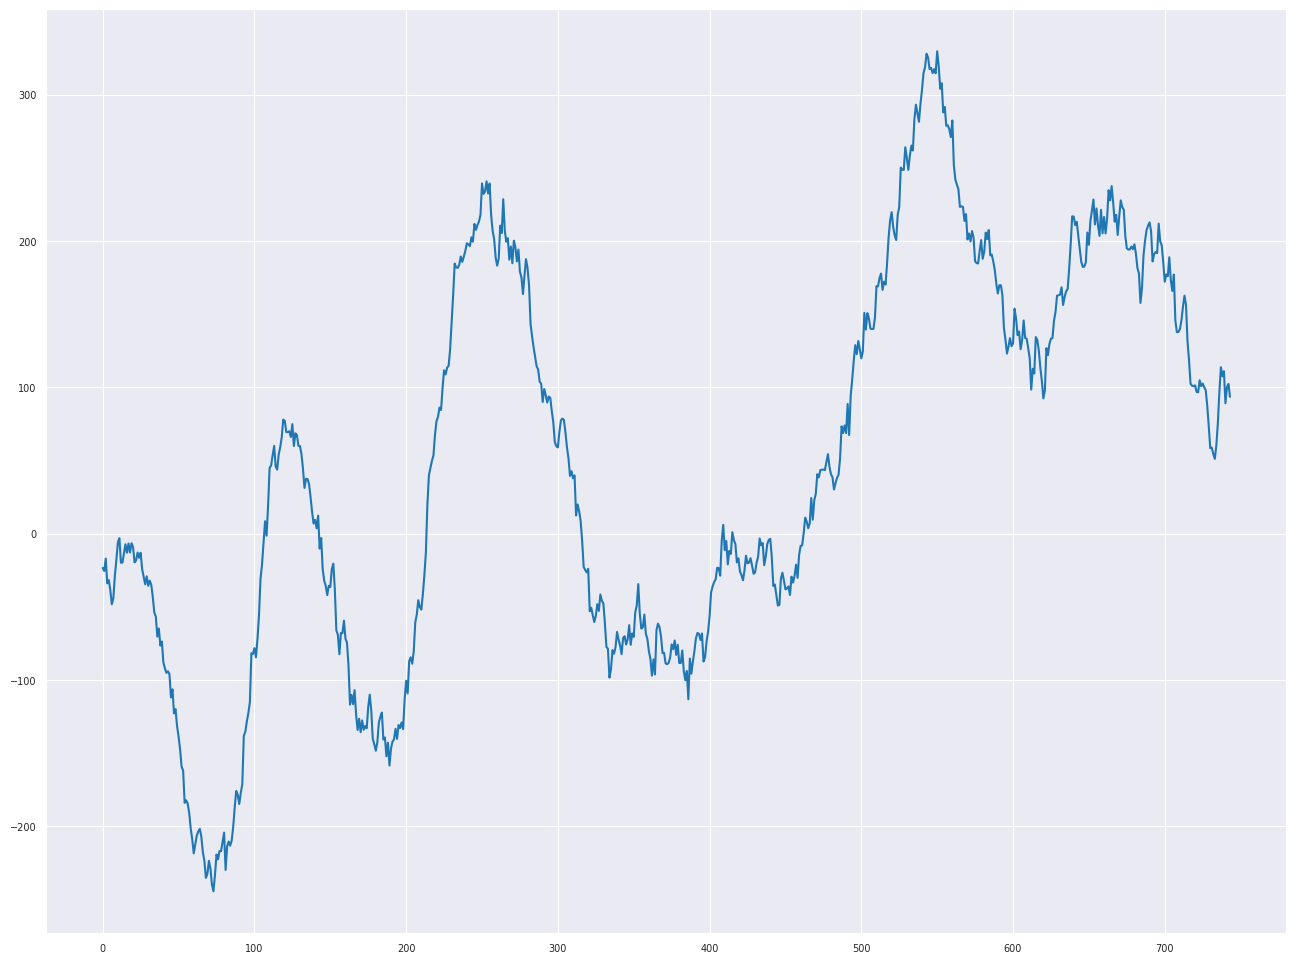

In [81]:
# Residuals during 2017/12
plt.plot(residual_point_best.resid[25560:])
plt.show()

In [20]:
def mstl_detrend(ts, periods):
    """
    Apply MSTL decomposition to a 1D numpy array and return the residuals.
    
    Parameters
    ----------
    ts : array_like
        Time series data.
    period : array_like
        Enter multiple seasonal period you suspect in an array form. For 
        instance, if we suspect daily and weekly periodicity, we enter 
        period = [24, 24*5]
    
    Returns
    -------
    detrended_ts : numpy array
        The residual time series after removing the seasonal component.
    """
    detrend = MSTL(ts, periods=periods).fit()
    return detrend.resid

periods = [4, 4*5]

residuals = xr.apply_ufunc(
    mstl_detrend,       
    data['z'].load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

# residuals for GP regression.
print(residuals)

<xarray.DataArray 'z' (lat: 32, lon: 64, time: 248)> Size: 4MB
array([[[ 303.33076391,  232.61896834,  154.78392919, ...,
          -44.04829468, -106.29780351, -195.08741801],
        [ 312.13307572,  242.46986038,  163.00359374, ...,
          -45.25566951, -117.731815  , -206.32133833],
        [ 323.55461406,  254.40688839,  176.65946617, ...,
          -45.90361506, -125.29201967, -216.71176038],
        ...,
        [ 279.00291481,  209.38173591,  127.05902582, ...,
          -34.24131049,  -70.38062926, -139.58572287],
        [ 283.59884511,  212.0261474 ,  138.09273023, ...,
          -35.34341467,  -83.072698  , -159.9308988 ],
        [ 292.33679795,  222.81546123,  145.31464834, ...,
          -41.49447357,  -94.31992884, -177.33545556]],

       [[ 199.99061683,  145.29302854,   70.15936467, ...,
           28.55043806,  -58.17528053, -138.84337907],
        [ 219.16792143,  160.45234546,   83.30819075, ...,
           23.57933613,  -73.76834217, -160.2396146 ],
        [ 

## 2m Temp

In [3]:
t2m = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/2m_temperature/*.nc', combine='by_coords')
data = t2m.sel(time=slice('2015', '2017'))
point_worst = data['t2m'].sel(lat=65, lon=84.375, method='nearest')
point_best = data['t2m'].sel(lat=2.8125, lon=196.875, method='nearest')

Peak at frequency = 0.00011 cycles/hour (corresponding period = 8768.00 hrs = 365.33 days = 12.18 months), power = 5052440.50000
Peak at frequency = 0.00091 cycles/hour (corresponding period = 1096.00 hrs = 45.67 days = 1.52 months), power = 77837.17969
Peak at frequency = 0.04167 cycles/hour (corresponding period = 24.00 hrs = 1.00 days = 0.03 months), power = 60357.97656
Peak at frequency = 0.00019 cycles/hour (corresponding period = 5260.80 hrs = 219.20 days = 7.31 months), power = 54067.78906
Peak at frequency = 0.00034 cycles/hour (corresponding period = 2922.67 hrs = 121.78 days = 4.06 months), power = 50796.91016
Peak at frequency = 0.00046 cycles/hour (corresponding period = 2192.00 hrs = 91.33 days = 3.04 months), power = 43937.76953
Peak at frequency = 0.00068 cycles/hour (corresponding period = 1461.33 hrs = 60.89 days = 2.03 months), power = 33272.96094
Peak at frequency = 0.00004 cycles/hour (corresponding period = 26304.00 hrs = 1096.00 days = 36.53 months), power = 17057

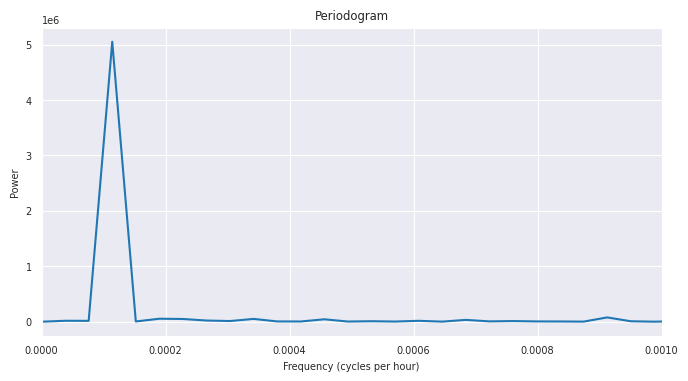

In [4]:
from scipy.signal import periodogram, find_peaks
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_worst.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:8]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.001)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

[]

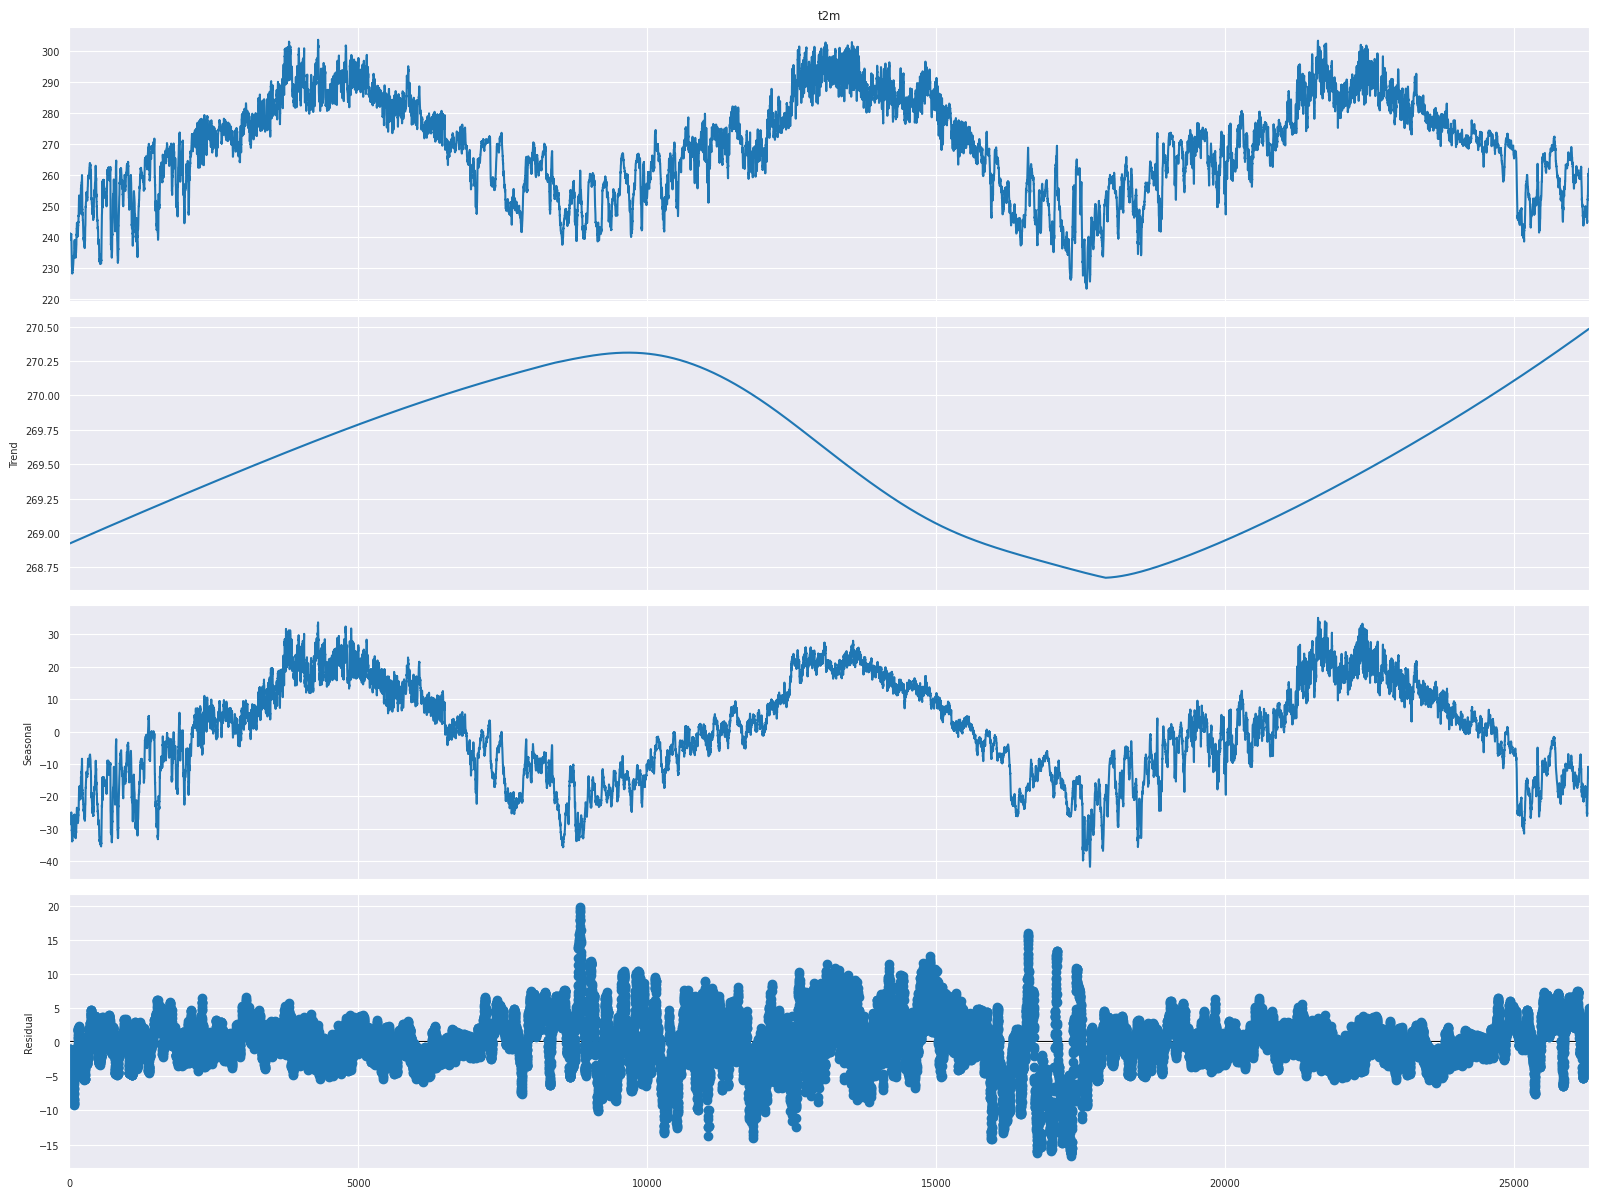

In [5]:
train_detrend_point_worst = STL(point_worst, period=8768)
train_residual_point_worst = train_detrend_point_worst.fit()
train_residual_point_worst.plot()
plt.plot()

[]

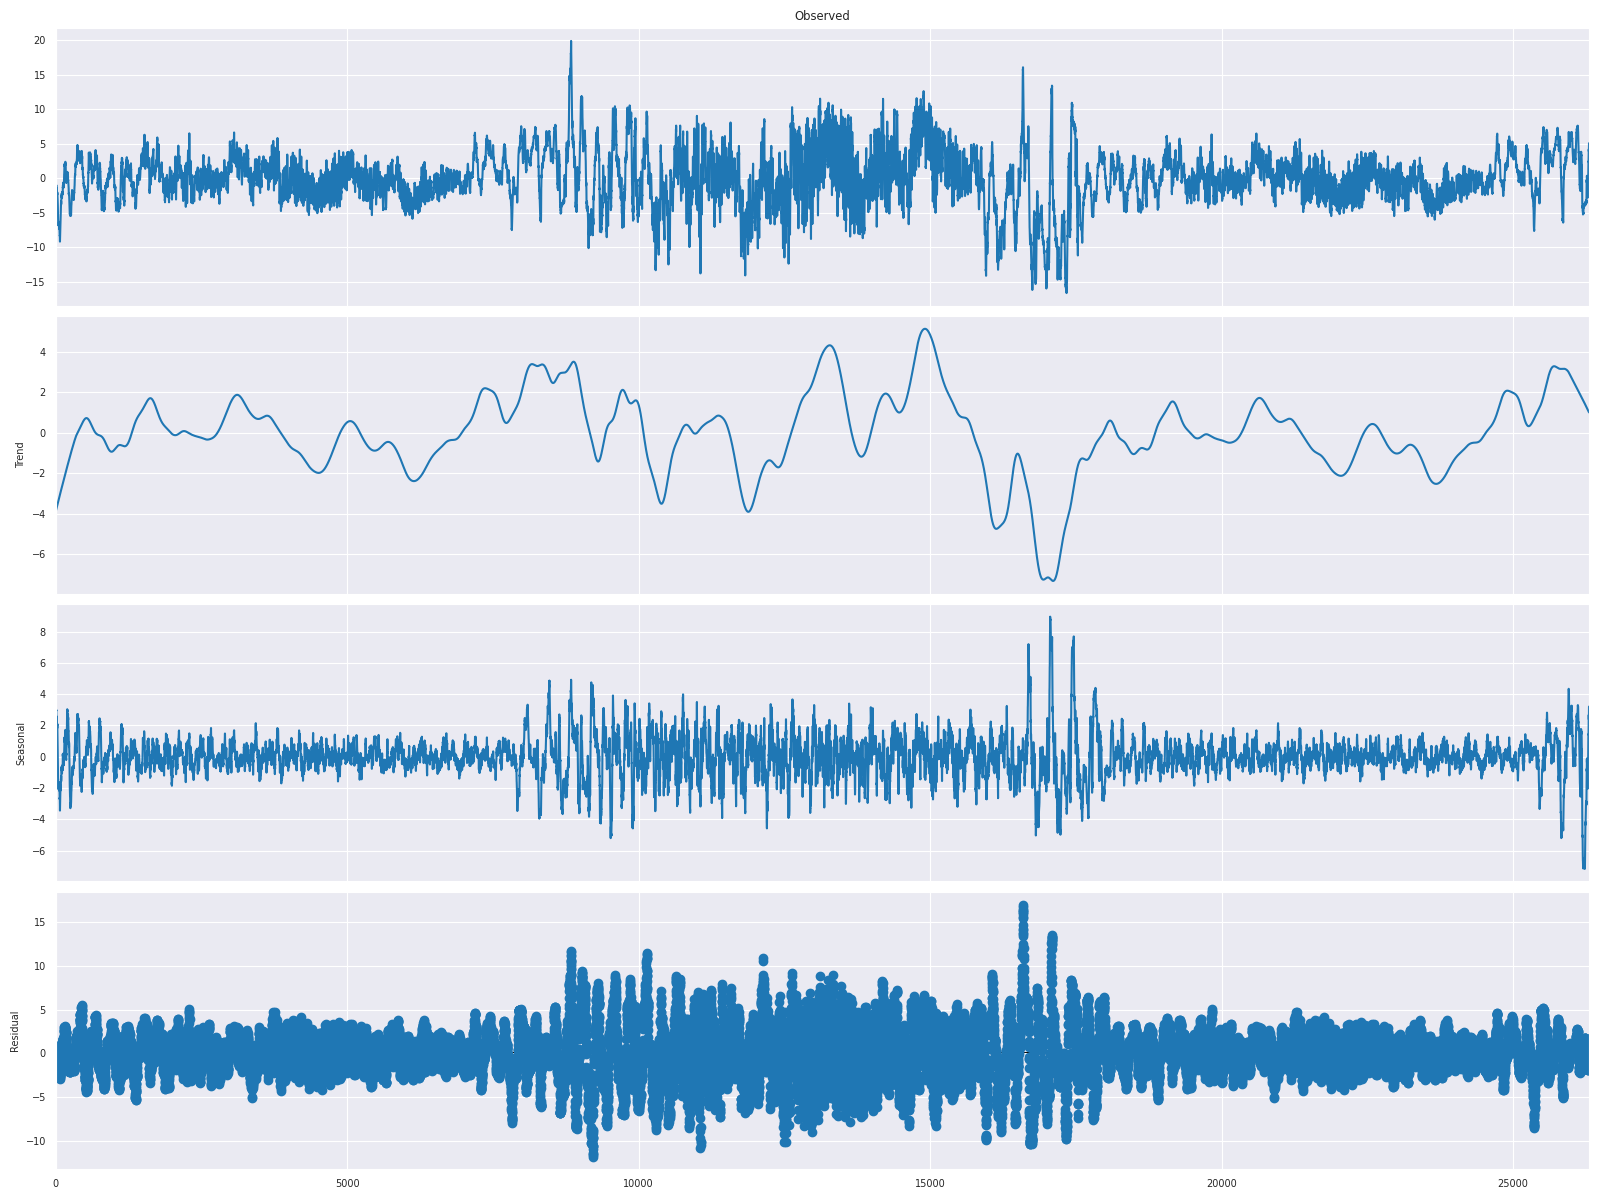

In [32]:
train_detrend2_point_worst = STL(train_residual_point_worst.resid, period=372)
train_residual2_point_worst = train_detrend2_point_worst.fit()
train_residual2_point_worst.plot()
plt.plot()

In [35]:
detrend3 = train_residual2_point_worst.resid[25560:]
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(detrend3, fs=fs)
peaks, properties = find_peaks(power, height=1, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:8]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")

Peak at frequency = 0.00941 cycles/hour (corresponding period = 106.29 hrs = 4.43 days = 0.15 months), power = 406.63806
Peak at frequency = 0.00403 cycles/hour (corresponding period = 248.00 hrs = 10.33 days = 0.34 months), power = 403.66620
Peak at frequency = 0.01747 cycles/hour (corresponding period = 57.23 hrs = 2.38 days = 0.08 months), power = 146.17274
Peak at frequency = 0.01478 cycles/hour (corresponding period = 67.64 hrs = 2.82 days = 0.09 months), power = 82.32120
Peak at frequency = 0.01210 cycles/hour (corresponding period = 82.67 hrs = 3.44 days = 0.11 months), power = 81.96453
Peak at frequency = 0.02016 cycles/hour (corresponding period = 49.60 hrs = 2.07 days = 0.07 months), power = 58.45227
Peak at frequency = 0.02823 cycles/hour (corresponding period = 35.43 hrs = 1.48 days = 0.05 months), power = 41.52661
Peak at frequency = 0.02285 cycles/hour (corresponding period = 43.76 hrs = 1.82 days = 0.06 months), power = 19.89944


[]

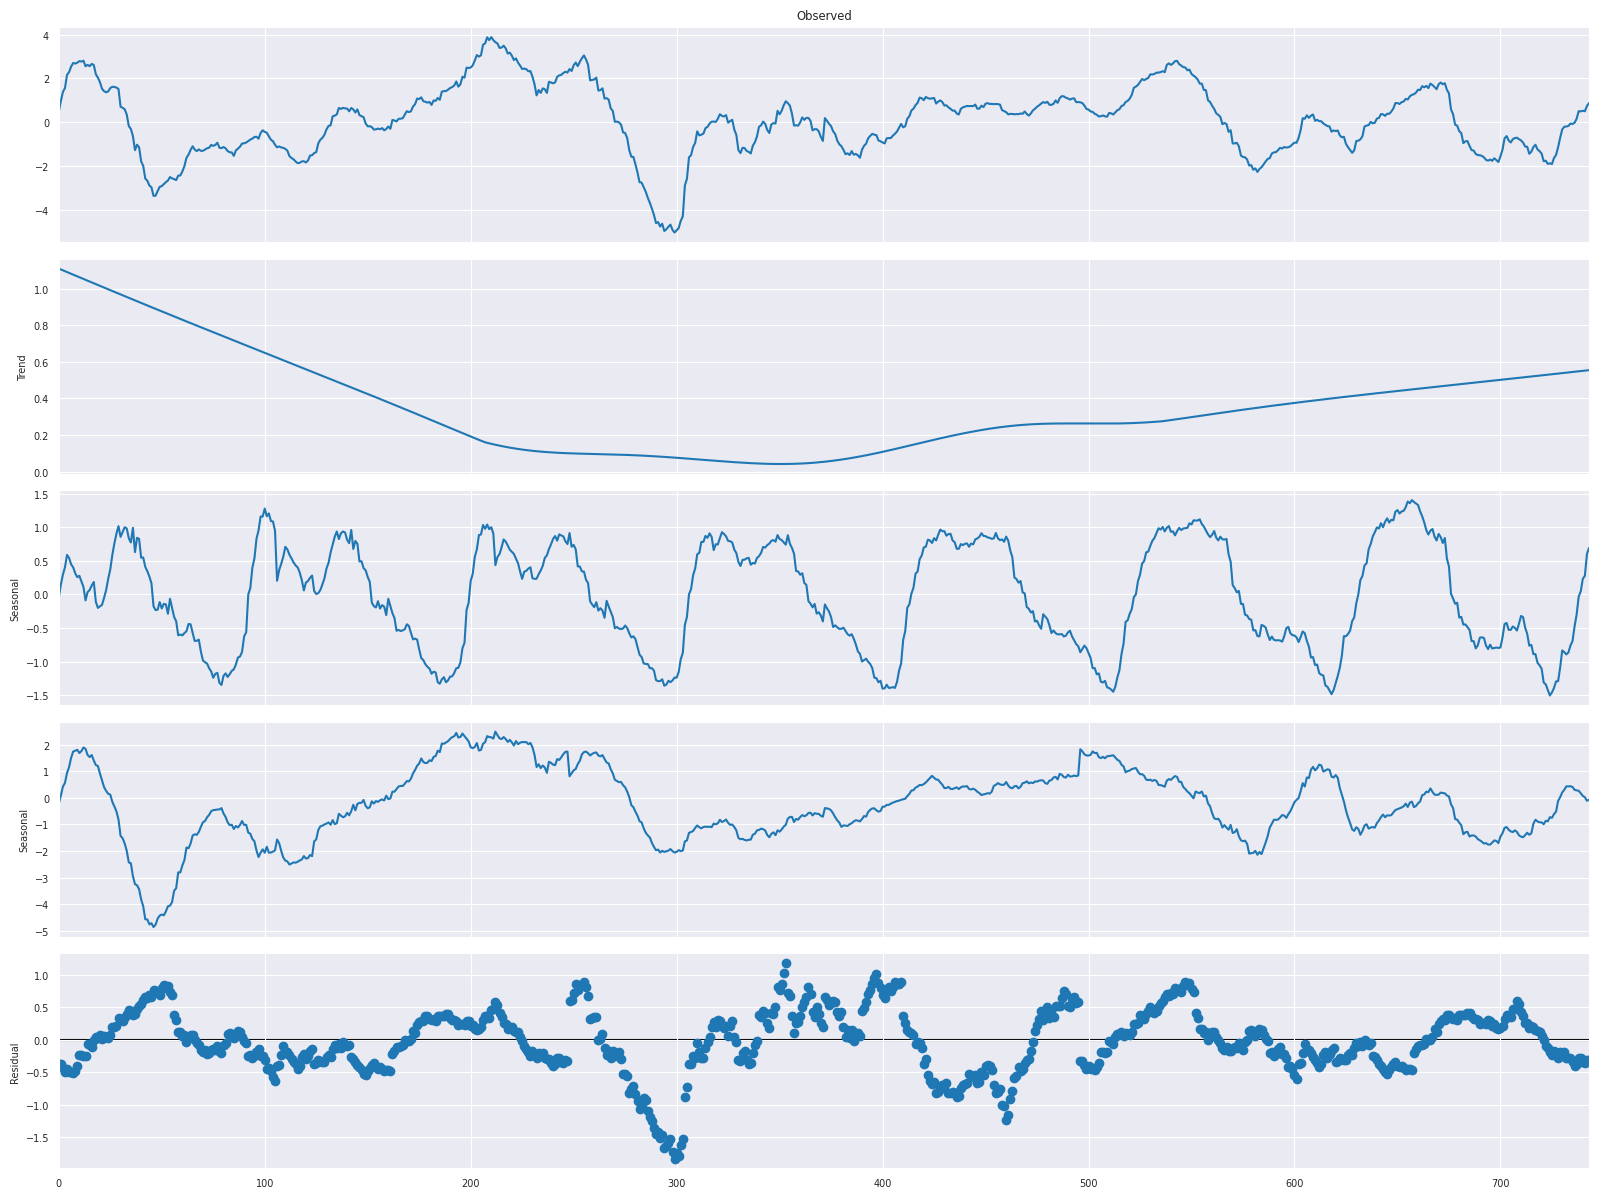

In [34]:
train_detrend3_point_worst = MSTL(detrend3, periods=[106, 248])
train_residual3_point_worst = train_detrend3_point_worst.fit()
train_residual3_point_worst.plot()
plt.plot()

In [36]:
detrend4 = train_residual3_point_worst.resid
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(detrend4, fs=fs)
peaks, properties = find_peaks(power, height=1, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:8]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")

Peak at frequency = 0.00672 cycles/hour (corresponding period = 148.80 hrs = 6.20 days = 0.21 months), power = 49.70117
Peak at frequency = 0.01344 cycles/hour (corresponding period = 74.40 hrs = 3.10 days = 0.10 months), power = 23.58498
Peak at frequency = 0.02285 cycles/hour (corresponding period = 43.76 hrs = 1.82 days = 0.06 months), power = 8.41650
Peak at frequency = 0.00941 cycles/hour (corresponding period = 106.29 hrs = 4.43 days = 0.15 months), power = 7.61821
Peak at frequency = 0.01747 cycles/hour (corresponding period = 57.23 hrs = 2.38 days = 0.08 months), power = 3.93498
Peak at frequency = 0.03091 cycles/hour (corresponding period = 32.35 hrs = 1.35 days = 0.04 months), power = 3.24470
Peak at frequency = 0.02554 cycles/hour (corresponding period = 39.16 hrs = 1.63 days = 0.05 months), power = 3.18390
Peak at frequency = 0.03360 cycles/hour (corresponding period = 29.76 hrs = 1.24 days = 0.04 months), power = 1.56321


[]

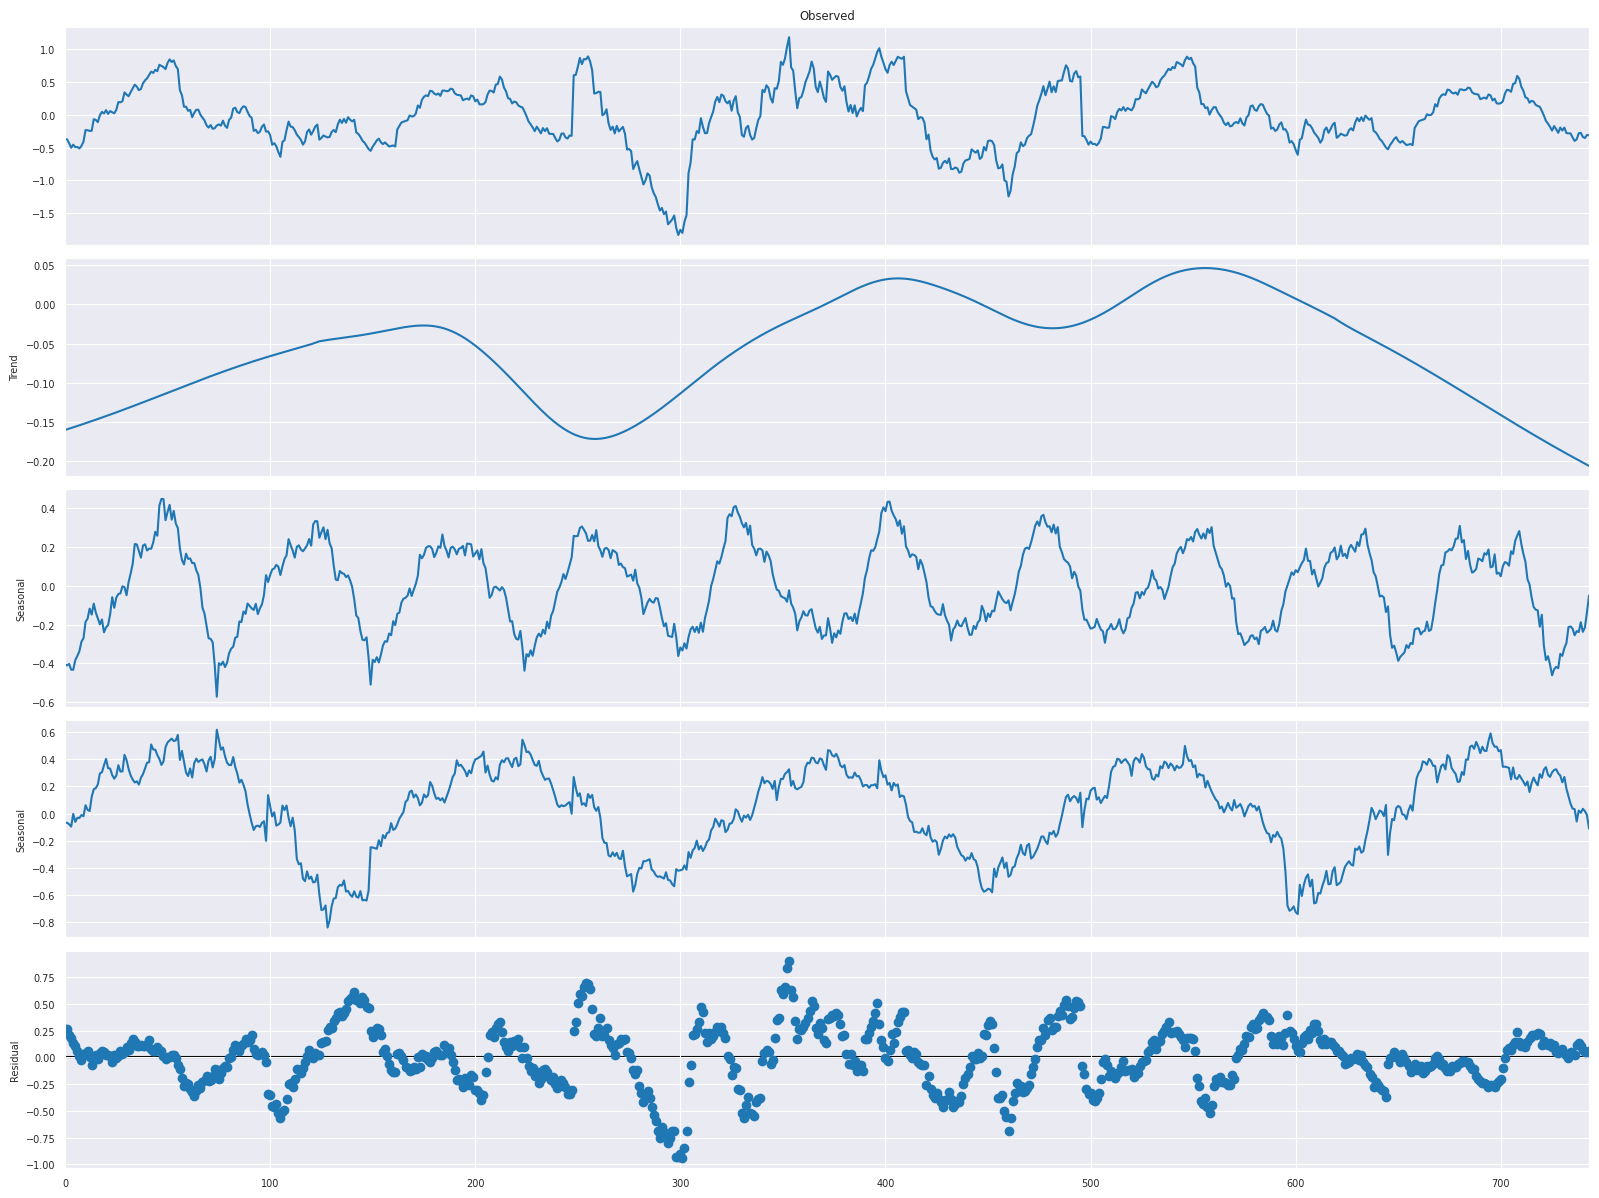

In [67]:
train_detrend4_point_worst = MSTL(detrend4, periods=[75, 149])
train_residual4_point_worst = train_detrend4_point_worst.fit()
train_residual4_point_worst.plot()
plt.plot()

In [68]:
detrend5 = train_residual4_point_worst.resid
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(detrend5, fs=fs)
peaks, properties = find_peaks(power, height=0, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:8]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")

Peak at frequency = 0.02285 cycles/hour (corresponding period = 43.76 hrs = 1.82 days = 0.06 months), power = 9.05276
Peak at frequency = 0.00806 cycles/hour (corresponding period = 124.00 hrs = 5.17 days = 0.17 months), power = 7.28334
Peak at frequency = 0.01747 cycles/hour (corresponding period = 57.23 hrs = 2.38 days = 0.08 months), power = 6.41542
Peak at frequency = 0.00538 cycles/hour (corresponding period = 186.00 hrs = 7.75 days = 0.26 months), power = 3.94761
Peak at frequency = 0.02957 cycles/hour (corresponding period = 33.82 hrs = 1.41 days = 0.05 months), power = 3.10378
Peak at frequency = 0.01478 cycles/hour (corresponding period = 67.64 hrs = 2.82 days = 0.09 months), power = 1.67481
Peak at frequency = 0.04301 cycles/hour (corresponding period = 23.25 hrs = 0.97 days = 0.03 months), power = 0.90532
Peak at frequency = 0.07124 cycles/hour (corresponding period = 14.04 hrs = 0.58 days = 0.02 months), power = 0.83431


[]

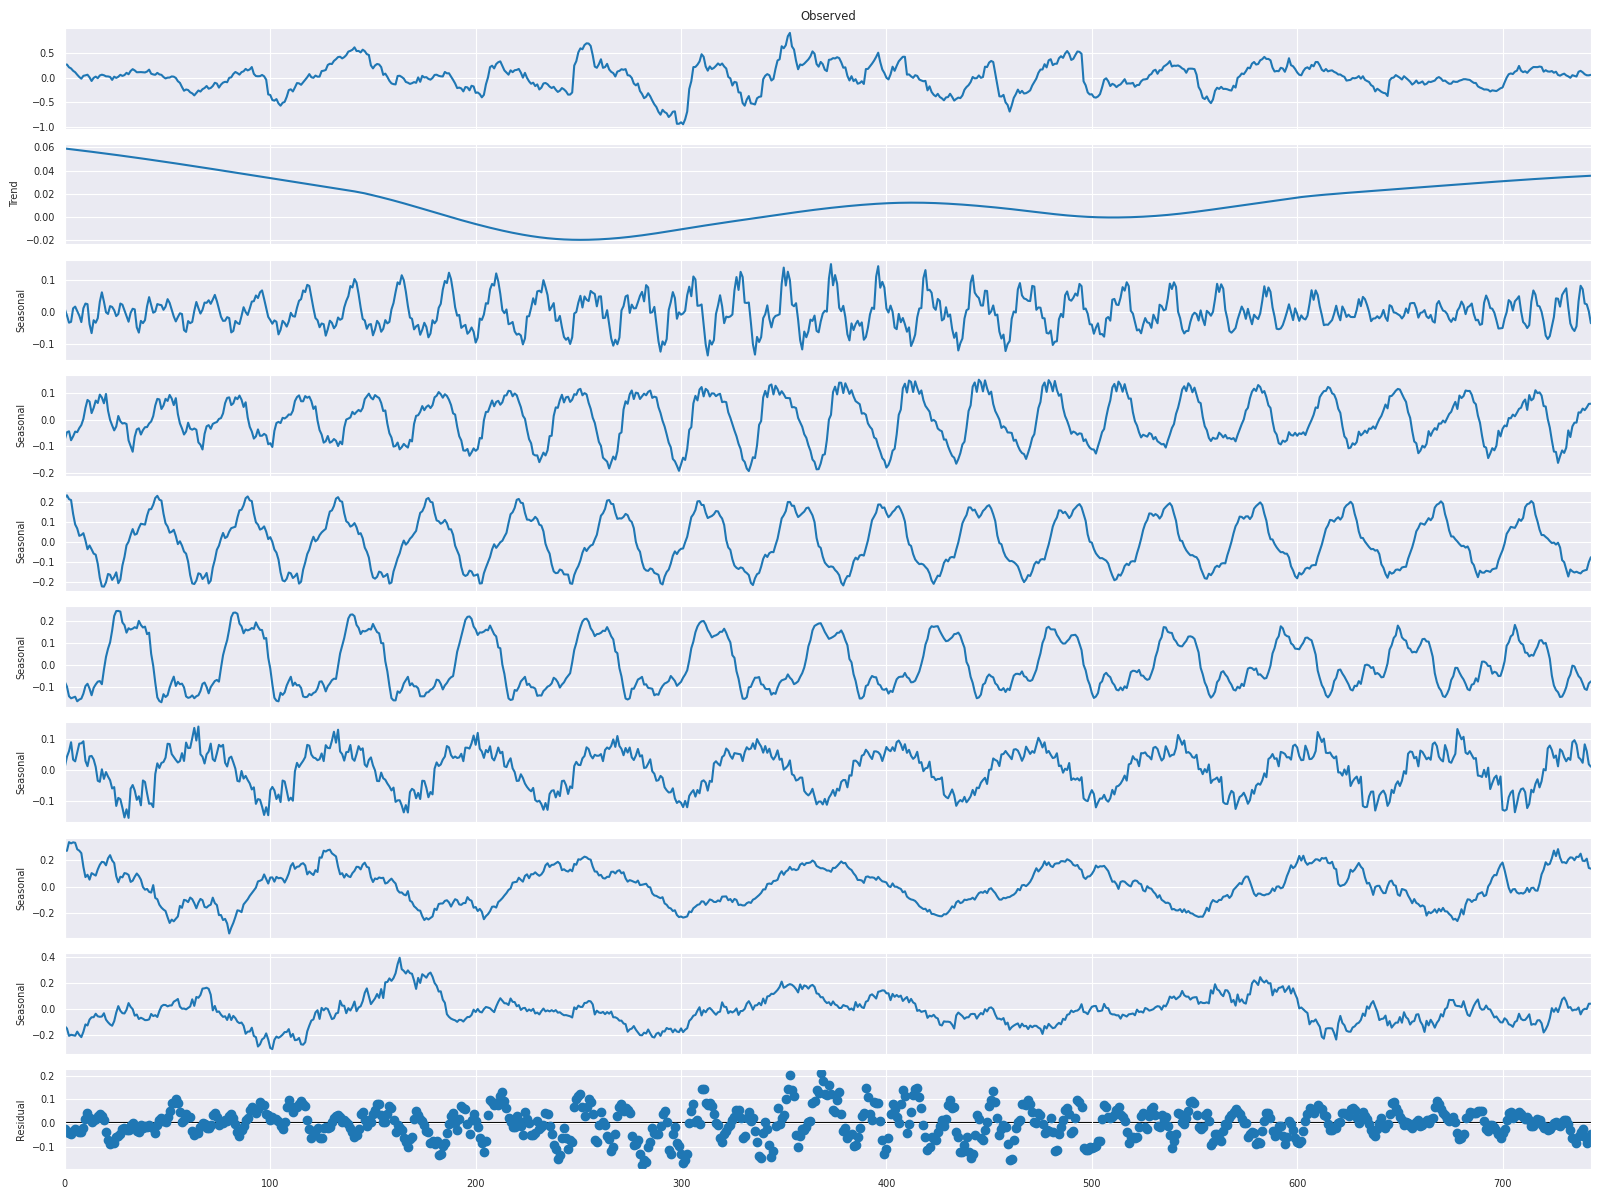

In [78]:
train_detrend5_point_worst = MSTL(detrend5, periods=[23, 34, 44, 57, 68, 124, 186])
train_residual5_point_worst = train_detrend5_point_worst.fit()
train_residual5_point_worst.plot()
plt.plot()

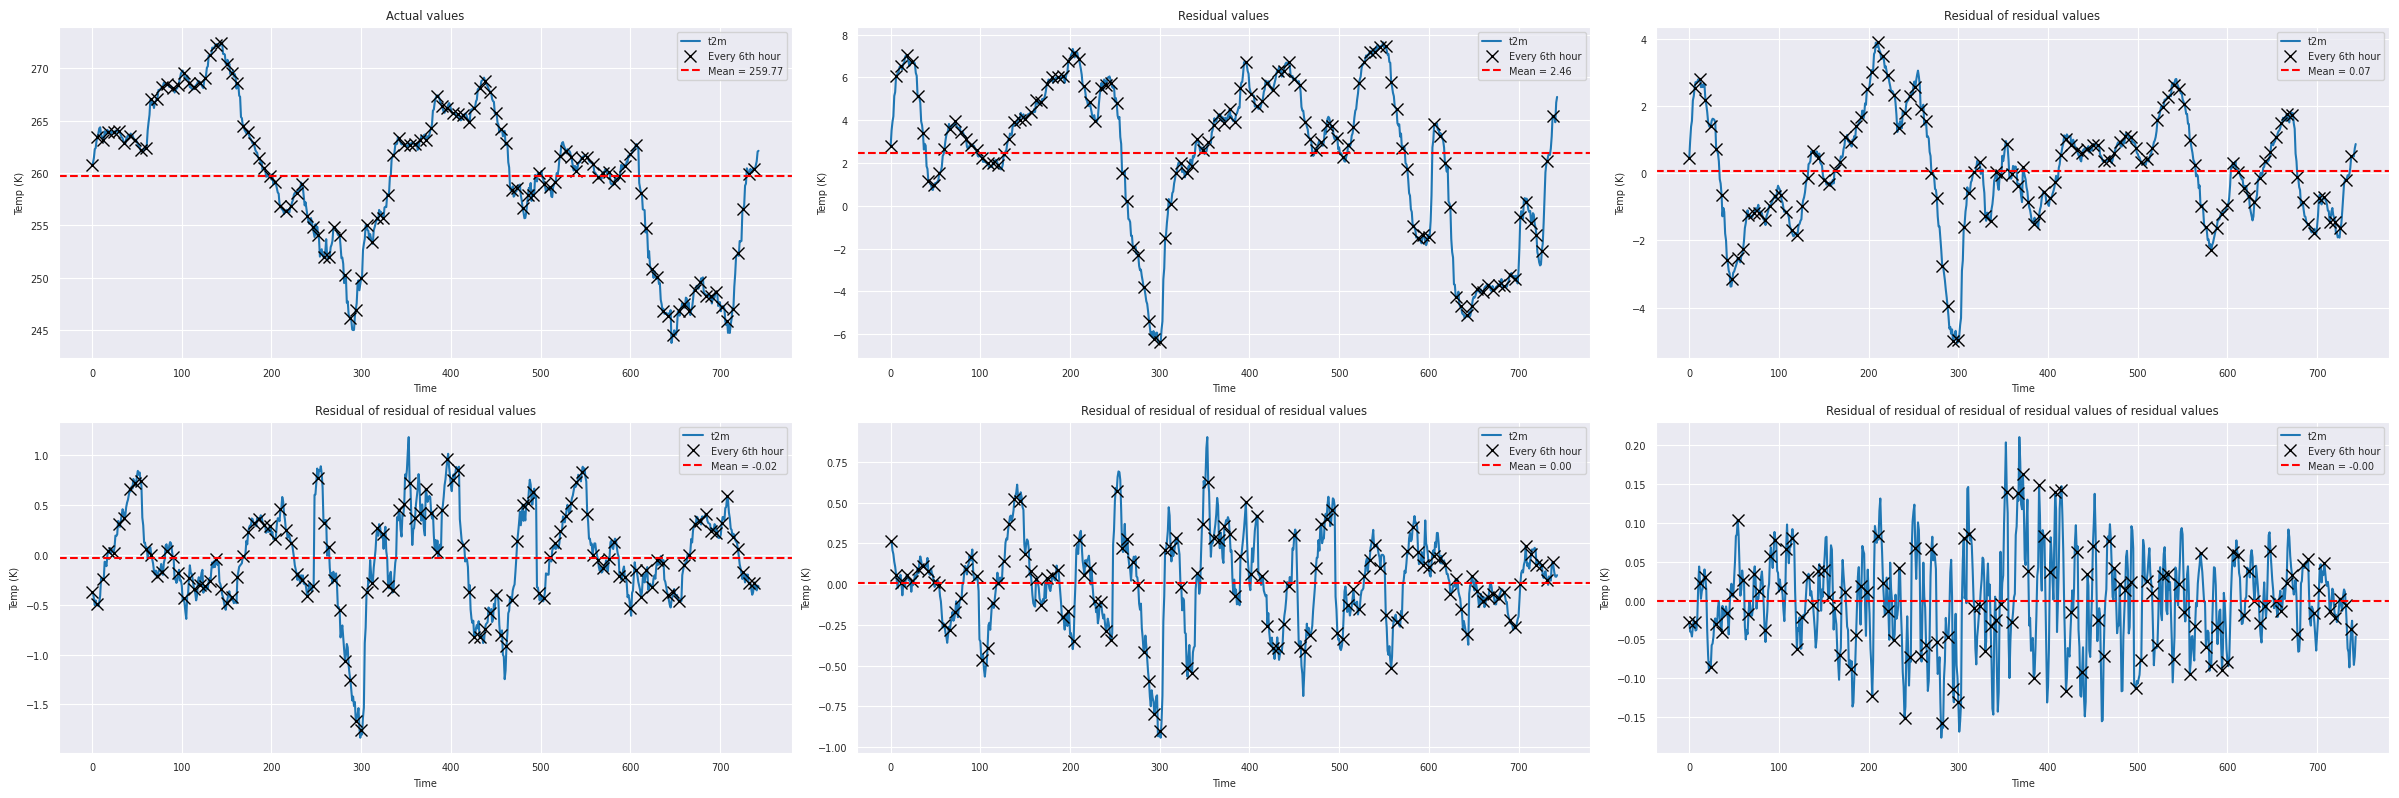

In [79]:
data_segment = point_worst.values[25560:]
x = np.arange(len(data_segment))

fig, axes = plt.subplots(2, 3, figsize=(24, 8))
mean_value = np.mean(data_segment)
axes[0][0].plot(x, data_segment, label="t2m")
axes[0][0].plot(x[::6], data_segment[::6], 'kx', markersize=8, label="Every 6th hour")
axes[0][0].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[0][0].set_title("Actual values")
axes[0][0].set_xlabel("Time")
axes[0][0].set_ylabel("Temp (K)")
axes[0][0].legend()

# Plot on the second subplot
mean_value = np.mean(train_residual_point_worst.resid[25560:])
axes[0][1].plot(x, train_residual_point_worst.resid[25560:], label="t2m")
axes[0][1].plot(x[::6], train_residual_point_worst.resid[25560:][::6], 'kx', markersize=8, label="Every 6th hour")
axes[0][1].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[0][1].set_title("Residual values")
axes[0][1].set_xlabel("Time")
axes[0][1].set_ylabel("Temp (K)")
axes[0][1].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual2_point_worst.resid[25560:])
axes[0][2].plot(x, train_residual2_point_worst.resid[25560:], label="t2m")
axes[0][2].plot(x[::6], train_residual2_point_worst.resid[25560:][::6], 'kx', markersize=8, label="Every 6th hour")
axes[0][2].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[0][2].set_title("Residual of residual values")
axes[0][2].set_xlabel("Time")
axes[0][2].set_ylabel("Temp (K)")
axes[0][2].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual3_point_worst.resid)
axes[1][0].plot(x, train_residual3_point_worst.resid, label="t2m")
axes[1][0].plot(x[::6], train_residual3_point_worst.resid[::6], 'kx', markersize=8, label="Every 6th hour")
axes[1][0].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[1][0].set_title("Residual of residual of residual values")
axes[1][0].set_xlabel("Time")
axes[1][0].set_ylabel("Temp (K)")
axes[1][0].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual4_point_worst.resid)
axes[1][1].plot(x, train_residual4_point_worst.resid, label="t2m")
axes[1][1].plot(x[::6], train_residual4_point_worst.resid[::6], 'kx', markersize=8, label="Every 6th hour")
axes[1][1].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[1][1].set_title("Residual of residual of residual of residual values")
axes[1][1].set_xlabel("Time")
axes[1][1].set_ylabel("Temp (K)")
axes[1][1].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual5_point_worst.resid)
axes[1][2].plot(x, train_residual5_point_worst.resid, label="t2m")
axes[1][2].plot(x[::6], train_residual5_point_worst.resid[::6], 'kx', markersize=8, label="Every 6th hour")
axes[1][2].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[1][2].set_title("Residual of residual of residual of residual values of residual values")
axes[1][2].set_xlabel("Time")
axes[1][2].set_ylabel("Temp (K)")
axes[1][2].legend()


plt.tight_layout()
plt.show()

In [ ]:
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_best.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:6]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.01)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

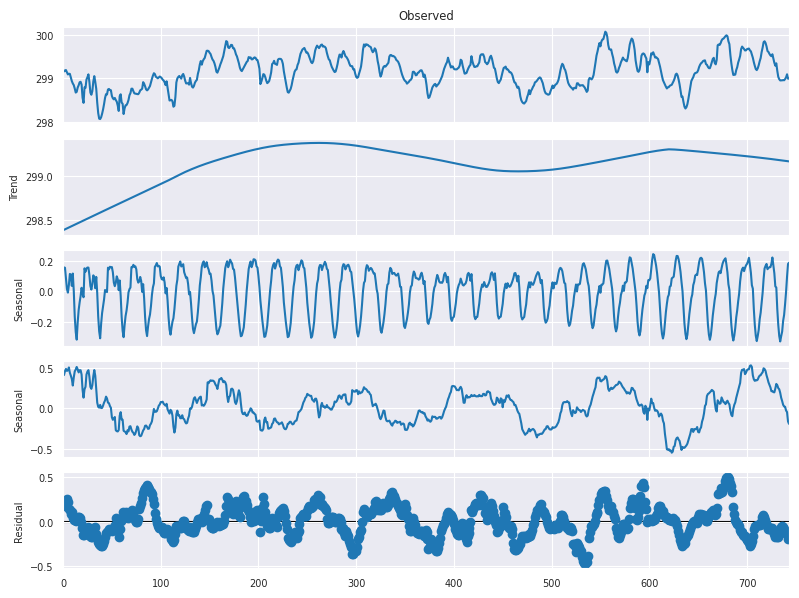

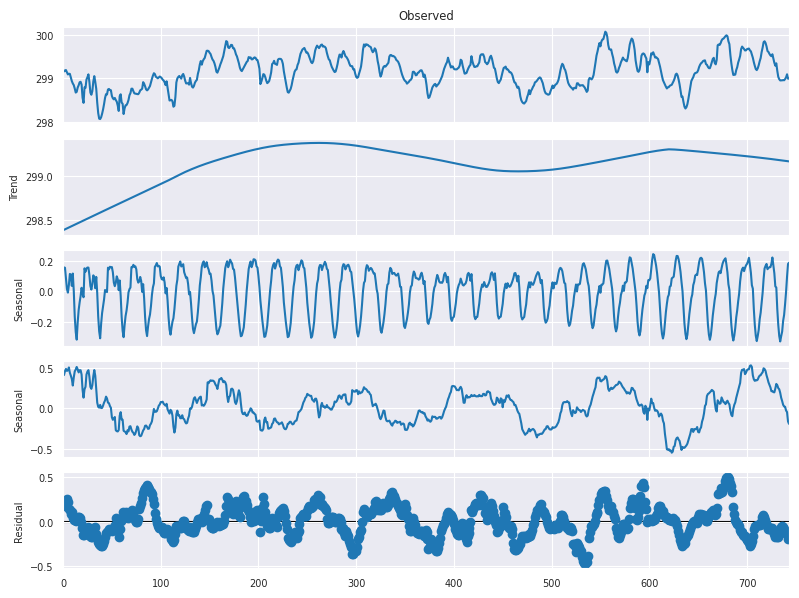

In [ ]:
detrend_point_best = MSTL(point_best, periods=[24, 148])
residual_point_best = detrend_point_best.fit()
residual_point_best.plot()
plt.plot()